In [270]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, precision_recall_curve, roc_auc_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE


In [271]:
# Cargamos de datos
df = pd.read_excel("Data/datos_limpios.xlsx")
df.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial
0,JKLXIQ,51,56857,102886,718,338,3,6.18,24,0.55,...,0,0,580.00,1,0,0,0,1,0,0
1,4UO7DJ,46,45840,30473,689,291,1,14.28,36,0.34,...,0,0,431.25,1,0,0,0,1,0,0
2,MO3OJW,36,48156,188824,675,161,2,13.35,36,0.55,...,0,0,760.00,0,0,1,0,0,1,0
3,I14TTP,42,41472,40000,582,312,1,11.83,12,0.44,...,1,0,385.66,0,1,0,0,0,1,0
4,8FUIBH,60,70202,40743,652,489,2,9.27,48,0.25,...,1,0,535.14,1,0,0,0,0,0,1


ANALISIS EXPLORATIORIO

In [272]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76510 entries, 0 to 76509
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   ID                                     76510 non-null  str    
 1   Edad                                   76510 non-null  int64  
 2   Ingresos                               76510 non-null  int64  
 3   Monto_Inicial                          76510 non-null  int64  
 4   Scoring_Crediticio                     76510 non-null  int64  
 5   Meses_Empleo                           76510 non-null  int64  
 6   Num_Creditos                           76510 non-null  int64  
 7   Ratio_Interes                          76510 non-null  float64
 8   Duracion                               76510 non-null  int64  
 9   Ratio_Deuda_Ingresos                   76510 non-null  float64
 10  Estudios                               76510 non-null  int64  
 11  Posesion_Hipo

In [273]:
#ESTADISTICAS DESCRIPTIVAS
display(df.describe())

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,...,Fiador,Impago,Prima,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial
count,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,...,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000,76510.000000
mean,39.649222,41470.404875,45118.745092,692.540505,212.443681,1.999333,10.661911,37.164710,0.321620,2.009959,...,0.299739,0.115789,384.771977,0.515135,0.183898,0.300967,0.149536,0.098876,0.552738,0.198850
std,10.078069,15917.680556,46679.312735,87.671057,150.753205,0.998875,3.800987,14.182585,0.180931,1.052333,...,0.458146,0.319974,267.321250,0.499774,0.387403,0.458681,0.356618,0.298497,0.497214,0.399137
min,19.000000,16000.000000,3000.000000,398.000000,0.000000,1.000000,2.010000,12.000000,0.100000,1.000000,...,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,30485.000000,15024.500000,636.000000,69.000000,1.000000,7.980000,24.000000,0.140000,1.000000,...,0.000000,0.000000,137.270000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,39091.500000,40000.000000,704.000000,207.000000,2.000000,10.590000,36.000000,0.290000,2.000000,...,0.000000,0.000000,335.945000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,46.000000,50041.750000,47716.000000,761.000000,337.000000,3.000000,13.220000,48.000000,0.550000,2.000000,...,1.000000,0.000000,612.847500,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,64.000000,120000.000000,400000.000000,845.000000,639.000000,4.000000,24.440000,60.000000,0.550000,4.000000,...,1.000000,1.000000,800.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [274]:
#VEMOS PROPORCION DE LA VARIABLE OBJETIVO
print("Número de observaciones por clase:")
print(df["Impago"].value_counts())
print("\nPorcentaje de observaciones por clase:")
print(df["Impago"].value_counts(normalize=True) * 100)

Número de observaciones por clase:
Impago
0    67651
1     8859
Name: count, dtype: int64

Porcentaje de observaciones por clase:
Impago
0    88.421121
1    11.578879
Name: proportion, dtype: float64


In [275]:
df.columns

Index(['ID', 'Edad', 'Ingresos', 'Monto_Inicial', 'Scoring_Crediticio',
       'Meses_Empleo', 'Num_Creditos', 'Ratio_Interes', 'Duracion',
       'Ratio_Deuda_Ingresos', 'Estudios', 'Posesion_Hipoteca',
       'Personas_Cargo', 'Fiador', 'Impago', 'Prima', 'Estado_Civil_Casado',
       'Estado_Civil_Divorciado', 'Estado_Civil_Soltero',
       'Tipo_Jornada_Laboral_Autónomo', 'Tipo_Jornada_Laboral_Desempleado',
       'Tipo_Jornada_Laboral_Jornada completa',
       'Tipo_Jornada_Laboral_Tiempo parcial'],
      dtype='str')

In [276]:
# Variables predictoras (X) y objetivo (y)
X = df[['Edad', 'Ingresos', 'Monto_Inicial', 'Scoring_Crediticio',
       'Meses_Empleo', 'Num_Creditos', 'Ratio_Interes',
       'Ratio_Deuda_Ingresos', 'Estudios', 'Fiador']] 
y = df["Impago"]

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=42,
    shuffle=True,
    stratify=y
)

Estandarizamos el dataset ya que los datos son muy desproporcionados

In [277]:
scaler = StandardScaler()
# Ajustamos y transformamos Train, solo transformamos Test
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

Realizamos undersampling y oversampling para igualar la cantidad de instancias que hay de la variable objetivo ya que esta muy desproporcionada

In [278]:
# 1. Undersampling: Reducimos la clase mayoritaria 0
undersampler = RandomUnderSampler(sampling_strategy={0: 30000}, random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)

# 2. SMOTE: Aumentamos la clase minoritaria 1
smote = SMOTE(sampling_strategy={1: 30000}, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_under, y_train_under)

print(f"Distribución final para entrenar -> 0: {sum(y_train_resampled==0)} | 1: {sum(y_train_resampled==1)}")

Distribución final para entrenar -> 0: 30000 | 1: 30000


In [279]:
# LogisticRegressionCV ya incluye la validación cruzada y la búsqueda de hiperparámetros
modelo_log_cv = LogisticRegressionCV(
    Cs=np.logspace(-4, 4, 50),
    cv=5,                       
    penalty='elasticnet',        # Combinación de L1 y L2
    l1_ratios=[0.1, 0.5, 0.9],            
    solver="saga",              # Optimizador requerido para L1
    scoring="roc_auc",          # Optimizamos para mejorar la curva ROC
    max_iter=5000,              
    random_state=42,
    use_legacy_attributes=False # Suprime avisos en versiones recientes
)

# Entrenamos el modelo con los datos balanceados
modelo_log_cv.fit(X_train_resampled, y_train_resampled)

c:\Users\asanz\VSCODE CARPETAS\bdata 2\RETO-5-Verde-Claro\reto5\Lib\site-packages\sklearn\linear_model\_logistic.py:2102: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",array([1.0000...00000000e+04])
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0.1, 0.5, ...]"
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add an L2 penalty term (used by default);- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'elasticnet'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy <accuracy_score>` is used... versionchanged:: 1.11 The default will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11.",'roc_auc'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty (`l1_ratio=0` for L2-penalty, `l1_ratio=

In [280]:
# Extracción del mejor hiperparámetro C
mejor_C = np.atleast_1d(modelo_log_cv.C_)[0]
print(f"Mejor valor del hiperparámetro C seleccionado por CV: {mejor_C:.4f}\n")

Mejor valor del hiperparámetro C seleccionado por CV: 0.5690



In [281]:
# Extraemos los coeficientes reales
coeficientes = np.atleast_1d(modelo_log_cv.coef_[0])

# Creamos tabla resumen
resumen_coeficientes = pd.DataFrame({
    "Variable": X_train_resampled.columns,
    "Coeficiente": coeficientes,
    "Importancia_Absoluta": np.abs(coeficientes)
})

resumen_coeficientes = resumen_coeficientes.sort_values(by="Importancia_Absoluta", ascending=False).reset_index(drop=True)

print("--- IMPORTANCIA DE VARIABLES (REGULARIZACIÓN L1) ---")
print("Nota: Un coeficiente de 0.0000 significa que Lasso descartó esa variable por no aportar información predictiva significativa.\n")
print(resumen_coeficientes.to_string(index=False))

# Verificamos la métrica en entrenamiento
roc_train = modelo_log_cv.score(X_train_resampled, y_train_resampled)
print(f"\nROC AUC en datos de entrenamiento: {roc_train:.4f}")

--- IMPORTANCIA DE VARIABLES (REGULARIZACIÓN L1) ---
Nota: Un coeficiente de 0.0000 significa que Lasso descartó esa variable por no aportar información predictiva significativa.

            Variable  Coeficiente  Importancia_Absoluta
       Ratio_Interes     0.461821              0.461821
                Edad    -0.300003              0.300003
        Meses_Empleo    -0.216352              0.216352
  Scoring_Crediticio    -0.090364              0.090364
       Monto_Inicial    -0.090253              0.090253
        Num_Creditos    -0.027968              0.027968
              Fiador    -0.019271              0.019271
            Estudios     0.017310              0.017310
            Ingresos    -0.016103              0.016103
Ratio_Deuda_Ingresos    -0.011811              0.011811

ROC AUC en datos de entrenamiento: 0.6879


In [282]:
# 1. Calculamos las probabilidades en el conjunto Test
probabilidades_test = modelo_log_cv.predict_proba(X_test_scaled)
probabilidades_clase_1 = probabilidades_test[:, 1]

# 2. Obtenemos métricas de la curva ROC para calcular el umbral ideal
fpr, tpr, thresholds_roc = roc_curve(y_test, probabilidades_clase_1)
umbral_optimo = thresholds_roc[np.argmax(tpr - fpr)]

print(f"Umbral matemático óptimo (Test): {umbral_optimo:.4f}")

# 3. Clasificación definitiva usando el umbral óptimo
clasificacion_test = np.where(probabilidades_clase_1 >= umbral_optimo, 1, 0)

Umbral matemático óptimo (Test): 0.5203


METRICAS DE ERROR

In [283]:
# Accuracy y Error Global
acierto = accuracy_score(y_test, clasificacion_test)
error = 1 - acierto
print(f"- Accuracy (Acierto Global): {acierto*100:.2f}%")
print(f"- Error Global: {error*100:.2f}%\n")

- Accuracy (Acierto Global): 66.49%
- Error Global: 33.51%



In [284]:
# Precision, Recall y F1-score
print(classification_report(y_test, clasificacion_test))

              precision    recall  f1-score   support

           0       0.93      0.67      0.78     13530
           1       0.20      0.64      0.31      1772

    accuracy                           0.66     15302
   macro avg       0.57      0.65      0.54     15302
weighted avg       0.85      0.66      0.72     15302



GRAFICOS

- ROC-AUC Score global: 0.6973



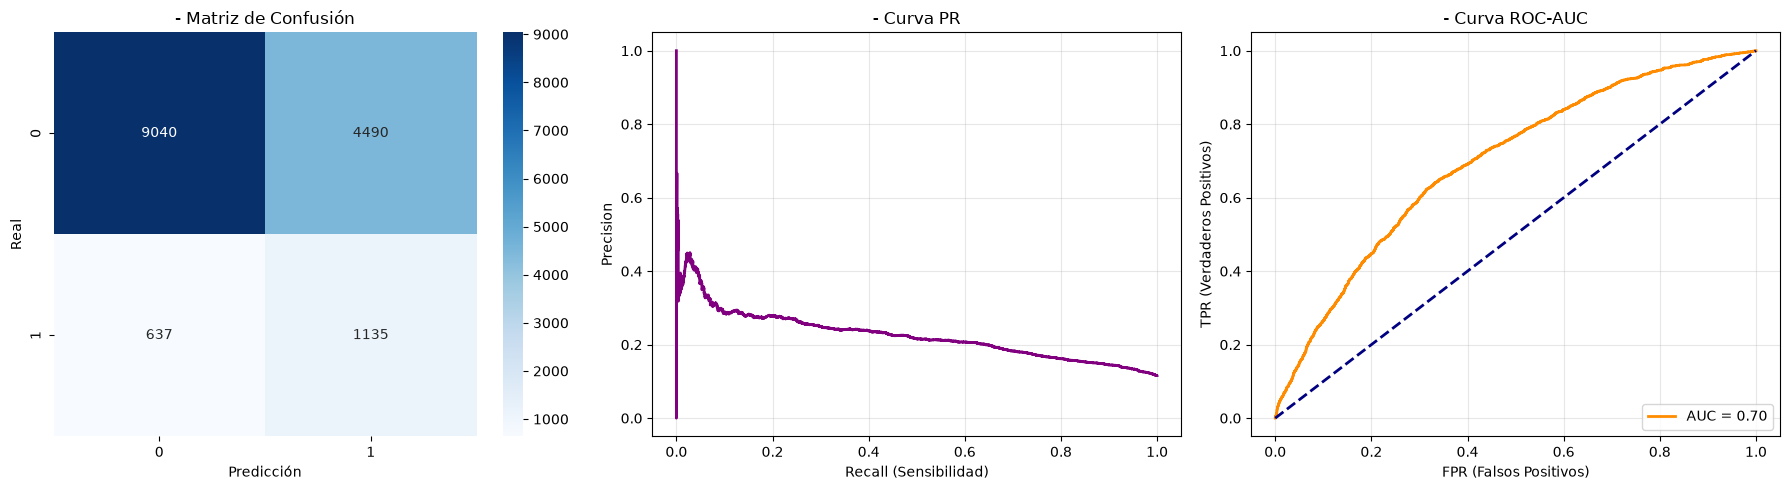

In [285]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de Confusión
c_matrix = confusion_matrix(y_test, clasificacion_test)
sns.heatmap(c_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("- Matriz de Confusión")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

# 2. Curva Precisión/Sensibilidad (PR Curve)
prec, rec, thresholds_pr = precision_recall_curve(y_test, probabilidades_clase_1)
axes[1].plot(rec, prec, color="purple", lw=2)
axes[1].set_xlabel("Recall (Sensibilidad)")
axes[1].set_ylabel("Precision")
axes[1].set_title("- Curva PR")
axes[1].grid(True, alpha=0.3)

# 3. Curva ROC

auc_score = roc_auc_score(y_test, probabilidades_clase_1)
print(f"- ROC-AUC Score global: {auc_score:.4f}\n")

axes[2].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc_score:.2f}")
axes[2].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[2].set_xlabel("FPR (Falsos Positivos)")
axes[2].set_ylabel("TPR (Verdaderos Positivos)")
axes[2].set_title("- Curva ROC-AUC")
axes[2].legend(loc="lower right")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ya que tenemos el modelo, ahora vamos a crear una nueva columna que diga la propabilidad de impago de cada cliente

In [ ]:
# 1. Estandarizamos el conjunto de datos completo (X) usando el escalador ajustado previamente
X_total_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index)

# 2. Calculamos las probabilidades para todos los clientes del dataset
probabilidades_totales = modelo_log_cv.predict_proba(X_total_scaled)

# 3. Extraemos la probabilidad
df["prob_impago"] = probabilidades_totales[:, 1]

--- PROBABILIDADES DE IMPAGO POR CLIENTE ---
       ID  Impago  prob_impago
0  JKLXIQ       0     0.192866
1  4UO7DJ       0     0.501288
2  MO3OJW       0     0.514376
3  I14TTP       0     0.461037
4  8FUIBH       0     0.204170
5  7DK4AB       0     0.685044
6  UTAX3Y       0     0.551041
7  R88ZD9       0     0.186958
8  54QB5O       0     0.413324
9  VSK4GD       0     0.234313


In [287]:
df.to_excel("Data/dataset_con_probabilidades.xlsx", index=False)